# 04. Keras 기본 워크플로우

이번 노트북에서는 Keras의 기본 흐름을 다시 정리합니다.

```text
데이터 준비 -> 모델 만들기 -> 컴파일 -> 학습 -> 예측
```

In [1]:
import numpy as np  # 숫자 배열을 만들고 다루기 위한 라이브러리입니다.
import matplotlib.pyplot as plt  # 학습 손실을 그래프로 보기 위한 라이브러리입니다.

from keras.models import Sequential  # 층을 순서대로 쌓는 Keras 모델입니다.
from keras.layers import Dense, Input  # Input은 입력 모양을 알려주고, Dense는 기본 신경망 층입니다.
from keras.optimizers import SGD  # SGD는 손실을 줄이는 방향으로 가중치를 조금씩 수정하는 최적화 방법입니다.

## 1. 데이터 준비

이번에도 `y = 2x + 1` 규칙을 사용합니다.

Keras 입력은 `(샘플 수, 특성 수)` 형태로 준비합니다.

In [2]:
# 샘플 5개, 특성 1개이므로 x_data의 모양은 (5, 1)입니다.
x_data = np.array([[0], [1], [2], [3], [4]], dtype=np.float32)

# 정답도 예측값과 비교하기 쉽게 (5, 1) 형태로 준비합니다.
y_data = np.array([[1], [3], [5], [7], [9]], dtype=np.float32)

print("x_data shape:", x_data.shape)
print("y_data shape:", y_data.shape)
print("x_data:", x_data.reshape(-1))
print("y_data:", y_data.reshape(-1))

x_data shape: (5, 1)
y_data shape: (5, 1)
x_data: [0. 1. 2. 3. 4.]
y_data: [1. 3. 5. 7. 9.]


## 2. 모델 만들기

`Sequential`은 층을 순서대로 쌓는 방식입니다.

이번 모델은 입력 1개를 받아 출력 1개를 만드는 가장 단순한 모델입니다.

In [3]:
model = Sequential([
    Input(shape=(1,)),  # 입력값이 1개라는 사실을 모델에게 알려줍니다.
    Dense(1)  # 출력값을 1개 만드는 층입니다. 이 안에 w와 b가 있습니다.
])

# summary()는 모델 구조와 학습할 숫자 개수를 보여줍니다.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 컴파일하기

`compile()`은 학습 방법을 설정합니다.

- `optimizer`: 손실을 줄이기 위해 내부 숫자를 어떻게 수정할지 정합니다.
- `loss`: 예측이 얼마나 틀렸는지 계산하는 기준입니다.

In [4]:
model.compile(
    optimizer=SGD(learning_rate=0.01),  # learning_rate는 한 번에 수정하는 크기입니다.
    loss="mse"  # 회귀 문제에서 자주 쓰는 평균 제곱 오차입니다.
)

## 4. 학습하기

`fit()`은 실제 학습을 수행합니다.

학습 결과는 `history`에 저장됩니다.

In [5]:
history = model.fit(
    x_data,  # 입력 데이터입니다.
    y_data,  # 정답 데이터입니다.
    epochs=200,  # 전체 데이터를 200번 반복해서 봅니다.
    verbose=0  # 학습 로그를 길게 출력하지 않습니다.
)

print("학습 완료")

학습 완료


## 5. 학습 과정 확인하기

`history.history["loss"]`에는 epoch마다 손실이 저장되어 있습니다.

첫 번째 손실: 63.7819938659668
마지막 손실: 1.3861421393812634e-05


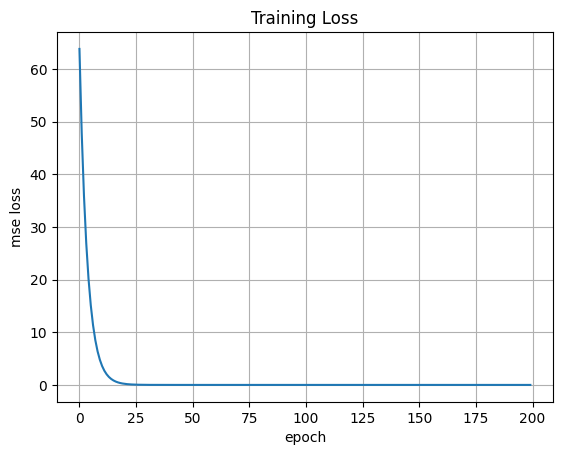

In [7]:
loss_values = history.history["loss"]

print("첫 번째 손실:", loss_values[0])
print("마지막 손실:", loss_values[-1])

plt.plot(loss_values)
plt.title("Training Loss")
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.grid(True)
plt.show()

## 6. 예측하기

`predict()`는 학습된 모델로 새 입력에 대한 예측을 만드는 메서드입니다.

In [6]:
new_x = np.array([[5], [10]], dtype=np.float32)  # 새 입력도 (샘플 수, 특성 수) 형태입니다.

pred = model.predict(new_x, verbose=0)

print("새 입력:", new_x.reshape(-1))
print("모델 예측:", pred.reshape(-1))
print("정답 규칙으로 계산하면:", (2 * new_x + 1).reshape(-1))

새 입력: [ 5. 10.]
모델 예측: [10.99518  20.983969]
정답 규칙으로 계산하면: [11. 21.]


## 7. 학습된 내부 숫자 확인하기

`get_weights()`로 모델이 학습한 가중치와 편향을 볼 수 있습니다.

In [8]:
weights, bias = model.get_weights()

print("학습된 w:", weights[0][0])
print("학습된 b:", bias[0])
print("정답에 가까운 값은 w=2, b=1입니다.")

학습된 w: 1.9977576
학습된 b: 1.0063927
정답에 가까운 값은 w=2, b=1입니다.


## 정리

Keras 기본 흐름은 다음과 같습니다.

```text
데이터 준비
모델 만들기
compile로 학습 방법 설정
fit으로 학습
predict로 예측
```

이 흐름은 앞으로 계속 반복됩니다.

## 과제

1. `compile()`과 `fit()`의 차이를 설명해보세요.
2. `epochs=20`으로 줄이면 손실과 예측이 어떻게 달라지는지 확인해보세요.
3. `learning_rate=0.1`로 바꾸면 어떤 일이 생기는지 확인해보세요.
4. `new_x`에 20을 추가해서 예측해보세요.